In [1]:
# !pip install xgboost
import pandas as pd
from collections import defaultdict
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from matplotlib import font_manager
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
import seaborn as sns
import joblib
import os
import xgboost as xgb

import psi4
from helper_CC_ML_spacial import *

font_path = 'Futura Book.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, size='large')
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams.update({'font.size': 12})

  Threads set to 12 by Python driver.


In [2]:
def formatter(x, pos):
    if x != 0:
        return f'{int(x/1000)}k'
    else:
        return 0

In [3]:
# Most important features (top 5 by SHAP):
# doublecheck: Numerator of the MP2 t2-amplitude, two-electron integral <ik || ab>
# t2start: Initial MP2 t2-amplitude
# t2mag: Magnitude of the MP2 t2-amplitude
# orbdiff: Denominator of the MP2 t2-amplitude
# diag: Binary feature denoting whether a=b (virtual orbits are the same)
top5 = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag']

# 31 Features order in X, including t2
properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag','t2']

# For some reason loading in the files and predicting the test set results in weird/bad performance. Perhaps this should be looked into... For now, I have just retrained the models from scratch, which seemed to have worked.

In [4]:
basis = "STO-3G"
n = 100

fn = f"out/optimised_{basis}_best_model_{n}.pkl"
model = joblib.load(fn)
print("Model loaded.")
print(model.steps, "\n")

/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model loaded.
[('scaler', MinMaxScaler(feature_range=(-1, 1))), ('xgb', XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=15,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=1, num_parallel_tree=None, ...))] 



/home/max/miniconda3/envs/quantum/lib/python3.10/pickle.py:1718: UserWarning: [16:50:19] WARNING: /workspace/src/collective/../data/../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
# splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_{basis}_data_splits_{n}.pkl")
#splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_sto_3g_pVDZ_data_splits_20.pkl")
splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/DDLUCJ/data/{basis}_test_data_splits.pkl"
data = joblib.load(splits_fn)
print("Data splits loaded.")

X_test = data["X_test"]
y_test = data["y_test"]

y_pred = model.predict(X_test)
error = y_pred - y_test
print("Predicted test set.")

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}")

Data splits loaded.
Predicted test set.
N: 100, MAE: 9.970629861815327e-05, RMSE: 0.0005165228029620193, R2: 0.995625256327781


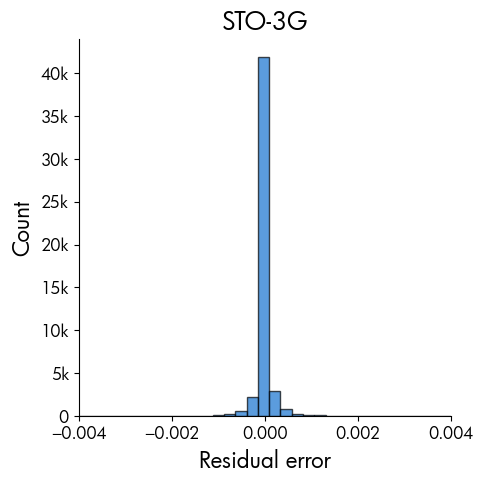

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(error, bins=200, edgecolor='black', alpha=0.7, color='#1573CF')

ax.set_xlabel('Residual error', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

ax.yaxis.set_major_formatter(FuncFormatter(formatter))
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')

plt.xlim(-0.004,0.004)
plt.title(basis, fontsize=18)
plt.tight_layout()
plt.show()

In [7]:
error = y_pred - y_test

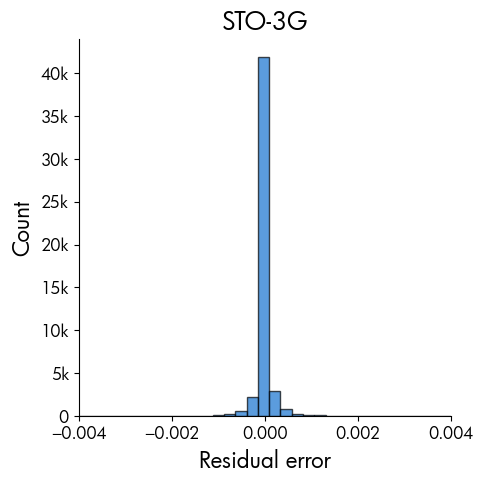

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(error, bins=200, edgecolor='black', alpha=0.7, color='#1573CF')

ax.set_xlabel('Residual error', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

ax.yaxis.set_major_formatter(FuncFormatter(formatter))
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')

plt.xlim(-0.004,0.004)
plt.title(basis, fontsize=18)
plt.tight_layout()
plt.show()

In [9]:
basis = "cc-pVDZ"
n = 100

fn = f"out/optimised_{basis}_best_model_{n}.pkl"
model = joblib.load(fn)
print("Model loaded.")
print(model.steps, "\n")

# splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_{basis}_data_splits_{n}.pkl")
#splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_sto_3g_pVDZ_data_splits_20.pkl")
splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/DDLUCJ/data/{basis}_test_data_splits.pkl"
data = joblib.load(splits_fn)
print("Data splits loaded.")

X_test_2 = data["X_test"]
y_test_2 = data["y_test"]

y_pred_2 = model.predict(X_test_2)
error_2 = y_pred_2 - y_test_2
print("Predicted test set.")

r2 = r2_score(y_test_2, y_pred_2)
mae = mean_absolute_error(y_test_2, y_pred_2)
rmse = root_mean_squared_error(y_test_2, y_pred_2)

print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}")

/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model loaded.
[('scaler', MinMaxScaler(feature_range=(-1, 1))), ('xgb', XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=20,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=1, num_parallel_tree=None, ...))] 

Data splits loaded.
Predicted test set.
N: 100, MAE: 3.026508345039079e-05, RMSE: 0.00037849364254323827, R2: 0.9062502607632762


In [10]:
error_2 = y_pred_2 - y_test_2

In [11]:
basis = "aug-cc-pVDZ"
n = 100

fn = f"out/optimised_{basis}_best_model_{n}.pkl"
model = joblib.load(fn)
print("Model loaded.")
print(model.steps, "\n")

# splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_{basis}_data_splits_{n}.pkl")
#splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_sto_3g_pVDZ_data_splits_20.pkl")
splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/DDLUCJ/data/{basis}_test_data_splits.pkl"
data = joblib.load(splits_fn)
print("Data splits loaded.")

X_test_3 = data["X_test"]
y_test_3 = data["y_test"]

y_pred_3 = model.predict(X_test_3)
error_3 = y_pred_3 - y_test_3
print("Predicted test set.")

r2 = r2_score(y_test_3, y_pred_3)
mae = mean_absolute_error(y_test_3, y_pred_3)
rmse = root_mean_squared_error(y_test_3, y_pred_3)

print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}")

/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model loaded.
[('scaler', MinMaxScaler(feature_range=(-1, 1))), ('xgb', XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=20,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=1, num_parallel_tree=None, ...))] 

Data splits loaded.
Predicted test set.
N: 100, MAE: 1.7797565517556075e-05, RMSE: 0.00018030884120503253, R2: 0.9295452422357313


In [12]:
error_3 = y_pred_3 - y_test_3

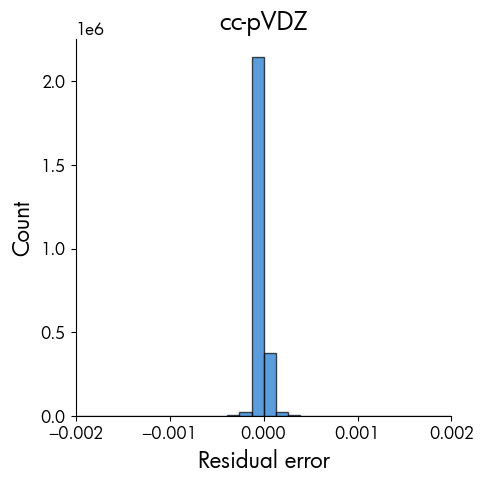

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(error_2, bins=1000, edgecolor='black', alpha=0.7, color='#1573CF')

ax.set_xlabel('Residual error', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

#ax.yaxis.set_major_formatter(FuncFormatter(formatter))
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')

plt.xlim(-0.002,0.002)
plt.title("cc-pVDZ", fontsize=18)
plt.tight_layout()
plt.show()

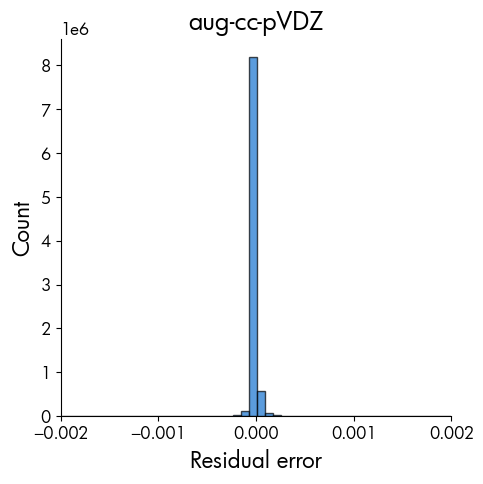

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(error_3, bins=1000, edgecolor='black', alpha=0.7, color='#1573CF')

ax.set_xlabel('Residual error', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

#ax.yaxis.set_major_formatter(FuncFormatter(formatter))
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')

plt.xlim(-0.002,0.002)
plt.title("aug-cc-pVDZ", fontsize=18)
plt.tight_layout()
plt.show()

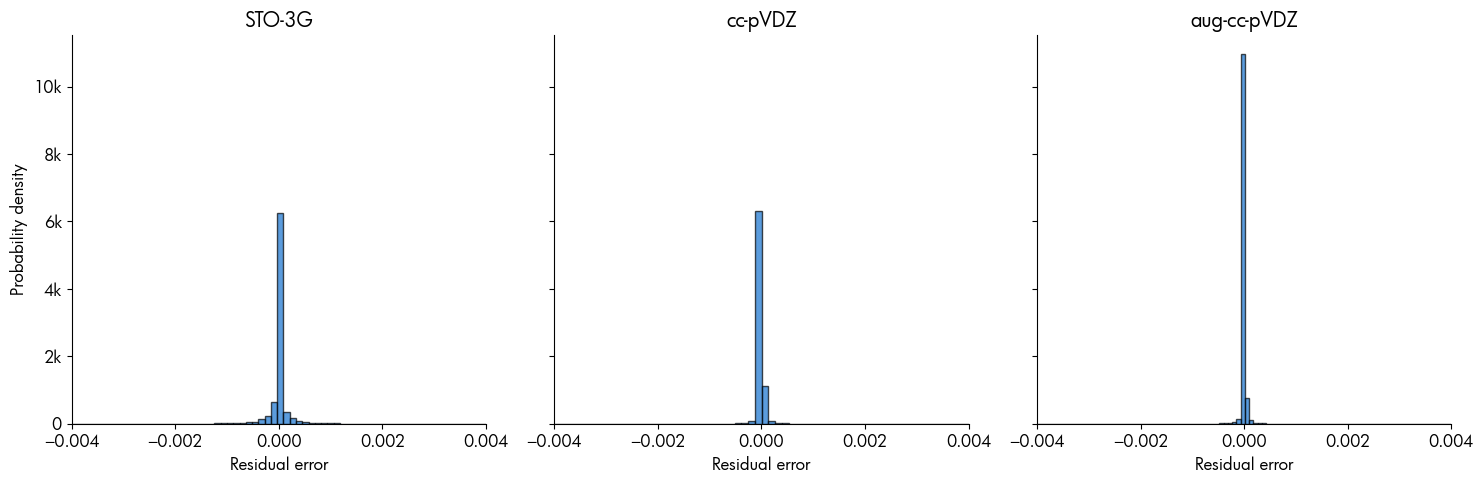

In [15]:
errors = [error, error_2, error_3]
titles = ["STO-3G", "cc-pVDZ", "aug-cc-pVDZ"]
bins_sizes = [400, 1000, 1000]
# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
xticks = [-0.004, -0.002, 0.0, 0.002, 0.004]
for i, (err, title) in enumerate(zip(errors, titles)):
    #axs[i].hist(err, bins=1000, edgecolor='black', alpha=0.7, color='#1573CF')
    axs[i].hist(err, bins=bins_sizes[i], edgecolor='black', alpha=0.7, color='#1573CF', density=True)
    axs[0].set_ylabel('Probability density')
    axs[i].set_xlabel('Residual error')
    axs[i].set_xlim(-0.002, 0.002)
    axs[i].set_xticks(xticks)
    axs[i].set_title(title)
    axs[i].spines['top'].set_color('none')
    axs[i].spines['right'].set_color('none')
    #axs[i].set_yscale('log')
    axs[i].yaxis.set_major_formatter(FuncFormatter(formatter))

axs[0].set_ylabel('Probability density')


plt.tight_layout()
plt.savefig("figs/residual_error_distribution.svg", format='svg', dpi=300)
plt.show()

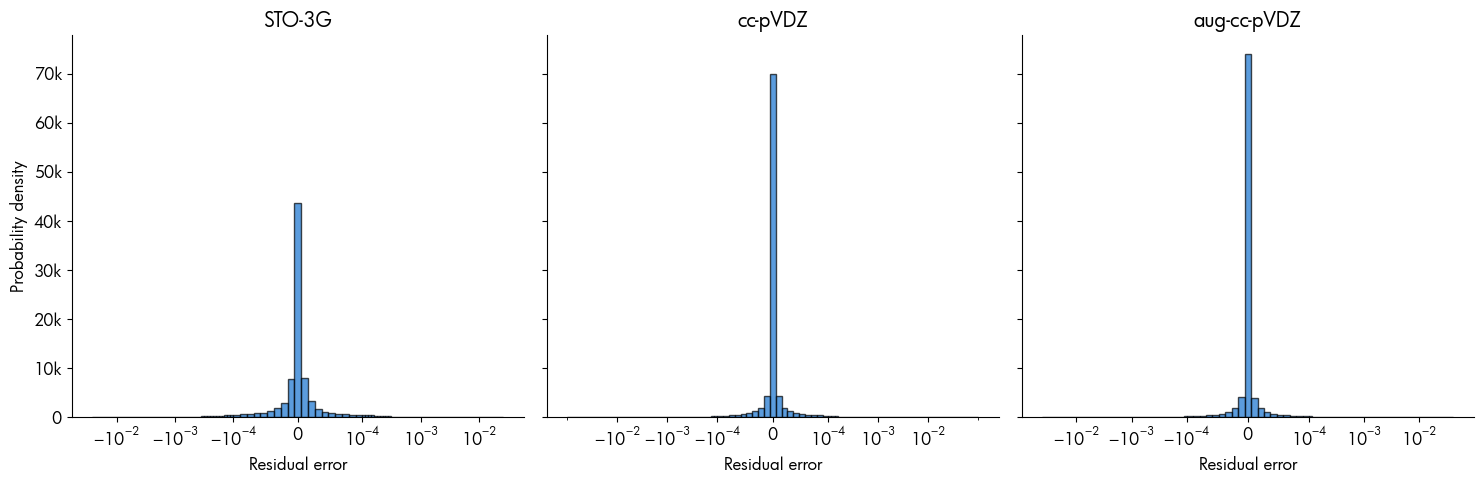

In [28]:
errors = [error, error_2, error_3]
titles = ["STO-3G", "cc-pVDZ", "aug-cc-pVDZ"]

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

xticks = [-1e-2, -1e-3, -1e-4, 0, 1e-4, 1e-3, 1e-2]
#xticklabels = [-1e-2, -1e-3, -1e-4, 0, 1e-4, 1e-3, 1e-2]

linthresh = 1e-4
n_bins_log = 50
n_bins_lin = 20

for i, (err, title) in enumerate(zip(errors, titles)):
    max_val = max(abs(np.min(err)), abs(np.max(err)))
    bins = np.concatenate([
        -np.logspace(np.log10(linthresh), np.log10(max_val), n_bins_log)[::-1],  # negative log
        np.linspace(-linthresh, linthresh, n_bins_lin),                           # linear near zero
        np.logspace(np.log10(linthresh), np.log10(max_val), n_bins_log)           # positive log
    ])
    
    axs[i].hist(err, bins=bins, edgecolor='black', alpha=0.7, color='#1573CF', density=True)
    axs[i].set_xlabel('Residual error')
    axs[i].set_title(title)
    axs[i].set_xscale('symlog', linthresh=linthresh)
    
    axs[i].spines['top'].set_color('none')
    axs[i].spines['right'].set_color('none')

    #xticks
    axs[i].set_xscale('symlog', linthresh=linthresh)
    axs[i].set_xticks(xticks)
    #axs[i].set_xticklabels(xticklabels)
    
    axs[i].yaxis.set_major_formatter(FuncFormatter(formatter))

axs[0].set_ylabel('Probability density')

plt.tight_layout()
plt.savefig("figs/residual_error_distribution.png", dpi=300)
plt.show()

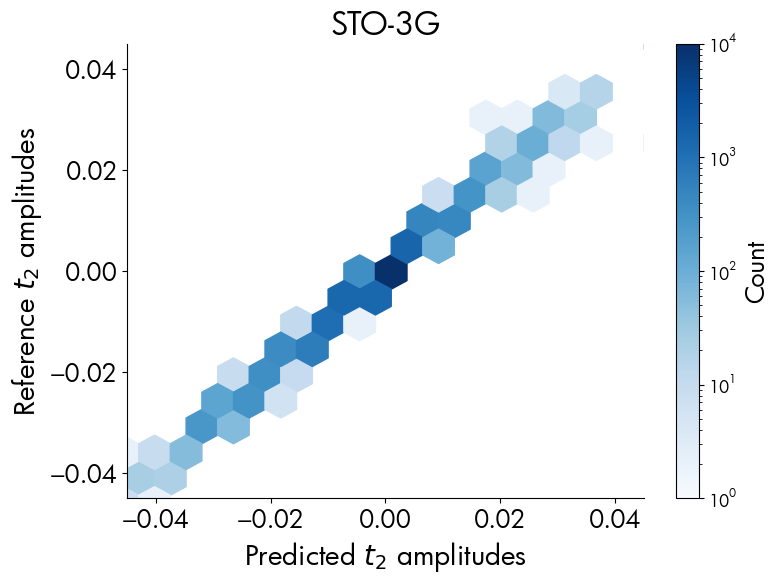

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(y_pred, y_test, gridsize=50, cmap='Blues', norm=LogNorm(vmin=1, vmax=10_000))

ax.set_xlabel('Predicted $t_2$ amplitudes', fontsize=20)
ax.set_ylabel('Reference $t_2$ amplitudes', fontsize=20)

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

xticks = [-0.04, -0.02, 0.00, 0.02, 0.04]
ax.set_xticks(xticks)
ax.set_yticks(xticks)
ax.tick_params(axis='both', labelsize=18)

ax.set_xlim(-0.045, 0.045)
ax.set_ylim(-0.045, 0.045)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Count', fontsize=18)
ax.set_title("STO-3G", fontsize=23)

plt.tight_layout()
plt.show()

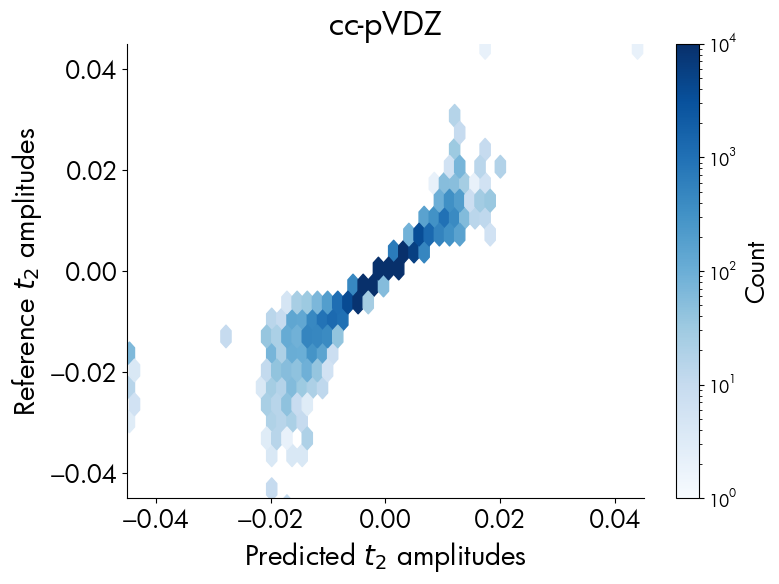

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(y_pred_2, y_test_2, gridsize=50, cmap='Blues', norm=LogNorm(vmin=1, vmax=10_000))

ax.set_xlabel('Predicted $t_2$ amplitudes', fontsize=20)
ax.set_ylabel('Reference $t_2$ amplitudes', fontsize=20)

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

xticks = [-0.04, -0.02, 0.00, 0.02, 0.04]
ax.set_xticks(xticks)
ax.set_yticks(xticks)
ax.tick_params(axis='both', labelsize=18)

ax.set_xlim(-0.045, 0.045)
ax.set_ylim(-0.045, 0.045)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Count', fontsize=18)
ax.set_title("cc-pVDZ", fontsize=23)

plt.tight_layout()
plt.show()

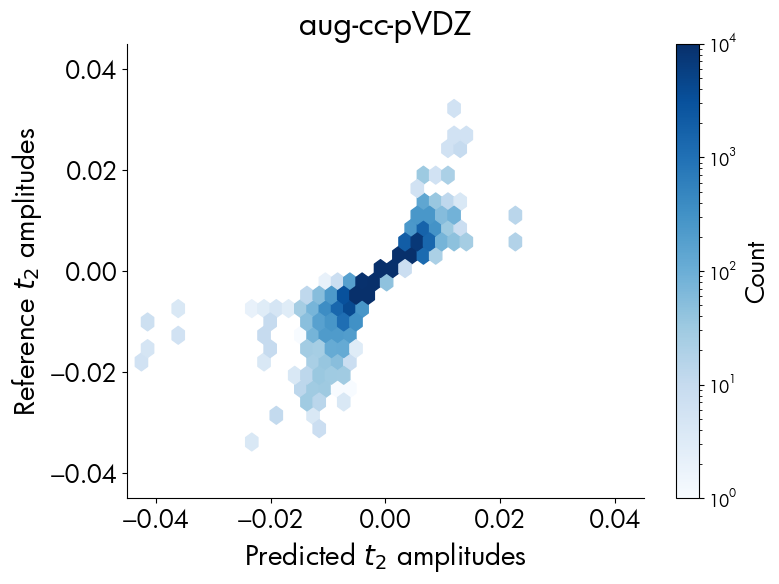

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(y_pred_3, y_test_3, gridsize=50, cmap='Blues', norm=LogNorm(vmin=1, vmax=10_000))

ax.set_xlabel('Predicted $t_2$ amplitudes', fontsize=20)
ax.set_ylabel('Reference $t_2$ amplitudes', fontsize=20)

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

xticks = [-0.04, -0.02, 0.00, 0.02, 0.04]
ax.set_xticks(xticks)
ax.set_yticks(xticks)
ax.tick_params(axis='both', labelsize=18)

ax.set_xlim(-0.045, 0.045)
ax.set_ylim(-0.045, 0.045)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Count', fontsize=18)
ax.set_title("aug-cc-pVDZ", fontsize=23)

plt.tight_layout()
plt.show()

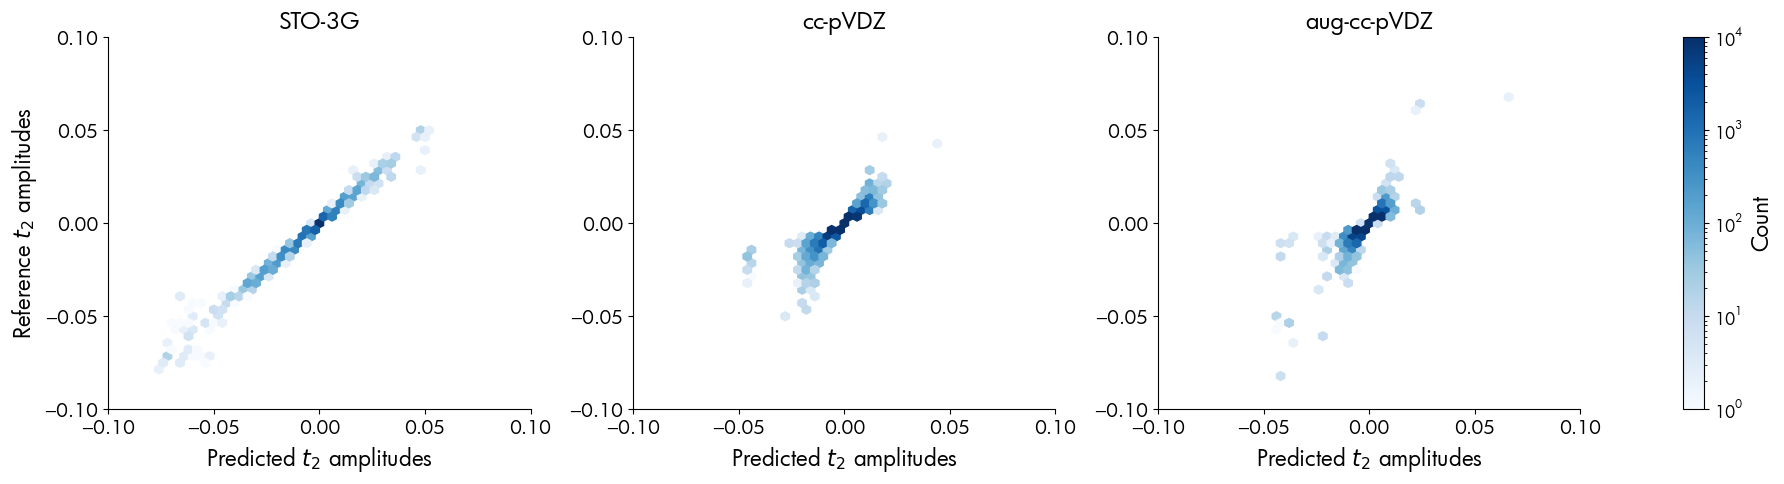

In [32]:
fig = plt.figure(figsize=(18, 5))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05]) 

predictions = [y_pred, y_pred_2, y_pred_3]
tests_subsets = [y_test, y_test_2, y_test_3]
titles = ["STO-3G", "cc-pVDZ", "aug-cc-pVDZ"]

axs = [plt.subplot(gs[i]) for i in range(3)]

for i, (y_p, title) in enumerate(zip(predictions, titles)):
    hb = axs[i].hexbin(
        y_p, tests_subsets[i],
        gridsize=50,
        cmap='Blues',
        norm=LogNorm(vmin=1, vmax=10_000),
        extent=(-0.1, 0.1, -0.1, 0.1)
    )
    axs[i].set_title(title, fontsize=17)
    axs[i].set_xlim(-0.1, 0.1)
    axs[i].set_ylim(-0.1, 0.1)

    xticks = [-0.1, -0.05, 0.00, 0.05, 0.1]
    axs[i].set_xticks(xticks)
    axs[i].set_yticks(xticks)
    axs[i].tick_params(axis='both', labelsize=14)


    axs[i].set_xlabel('Predicted $t_2$ amplitudes', fontsize=16)
    axs[i].spines['top'].set_color('none')
    axs[i].spines['right'].set_color('none')

axs[0].set_ylabel('Reference $t_2$ amplitudes', fontsize=16)

cax = plt.subplot(gs[3])
cbar = fig.colorbar(hb, cax=cax)
cbar.set_label('Count', fontsize=16)

plt.tight_layout()
plt.savefig("figs/residual_error_hex.svg", format='svg', dpi=300)
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


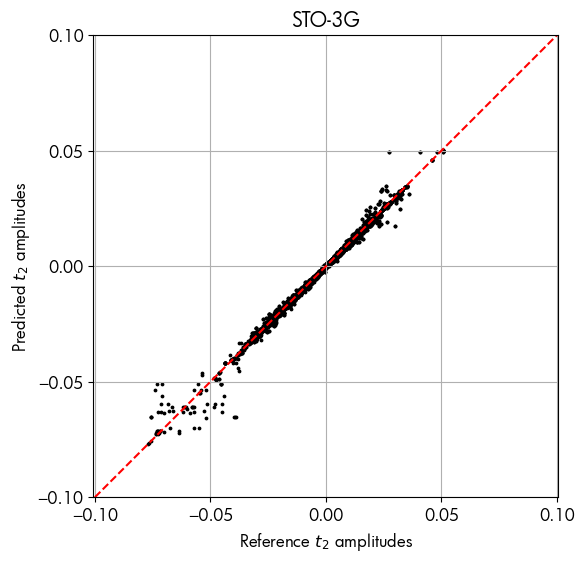

In [33]:
plt.figure(figsize=(6, 6))

plt.plot([-0.1, 0.1], [-0.1, 0.1], color='red', linestyle='--', label='Perfect Fit')

plt.scatter(y_test, y_pred, color='black', label='Predicted vs Reference', s=3)

plt.axis('equal')
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)
plt.xticks(np.arange(-0.1, 0.11, 0.05))
plt.yticks(np.arange(-0.1, 0.11, 0.05))

plt.title("STO-3G")
plt.xlabel('Reference $t_2$ amplitudes')
plt.ylabel('Predicted $t_2$ amplitudes')
plt.grid(True)

plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


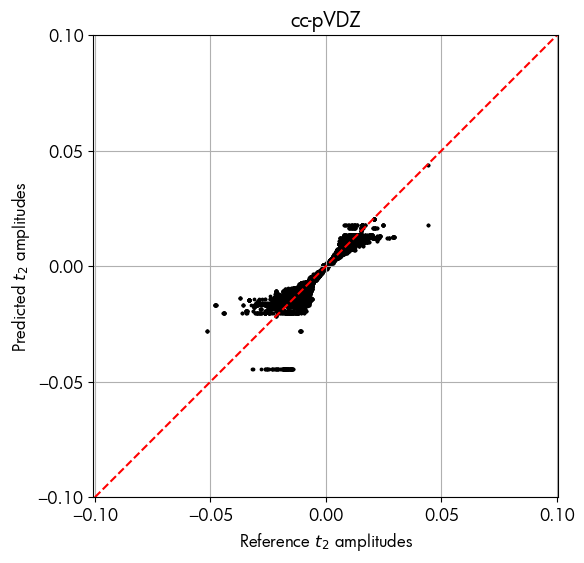

In [34]:
plt.figure(figsize=(6, 6))

plt.plot([-0.1, 0.1], [-0.1, 0.1], color='red', linestyle='--', label='Perfect Fit')

plt.scatter(y_test_2, y_pred_2, color='black', label='Predicted vs Reference', s=3)

plt.axis('equal')
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)
plt.xticks(np.arange(-0.1, 0.11, 0.05))
plt.yticks(np.arange(-0.1, 0.11, 0.05))

plt.title("cc-pVDZ")
plt.xlabel('Reference $t_2$ amplitudes')
plt.ylabel('Predicted $t_2$ amplitudes')
plt.grid(True)

plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


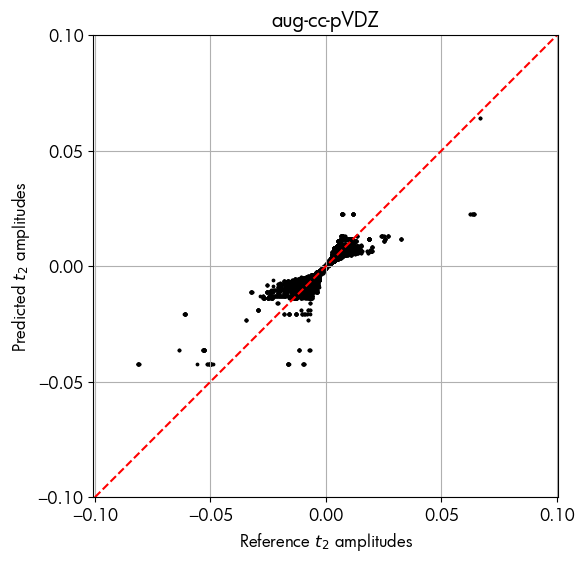

In [35]:
plt.figure(figsize=(6, 6))

plt.plot([-0.1, 0.1], [-0.1, 0.1], color='red', linestyle='--', label='Perfect Fit')

plt.scatter(y_test_3, y_pred_3, color='black', label='Predicted vs Reference', s=3)

plt.axis('equal')
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)
plt.xticks(np.arange(-0.1, 0.11, 0.05))
plt.yticks(np.arange(-0.1, 0.11, 0.05))

plt.title("aug-cc-pVDZ")
plt.xlabel('Reference $t_2$ amplitudes')
plt.ylabel('Predicted $t_2$ amplitudes')
plt.grid(True)

plt.show()

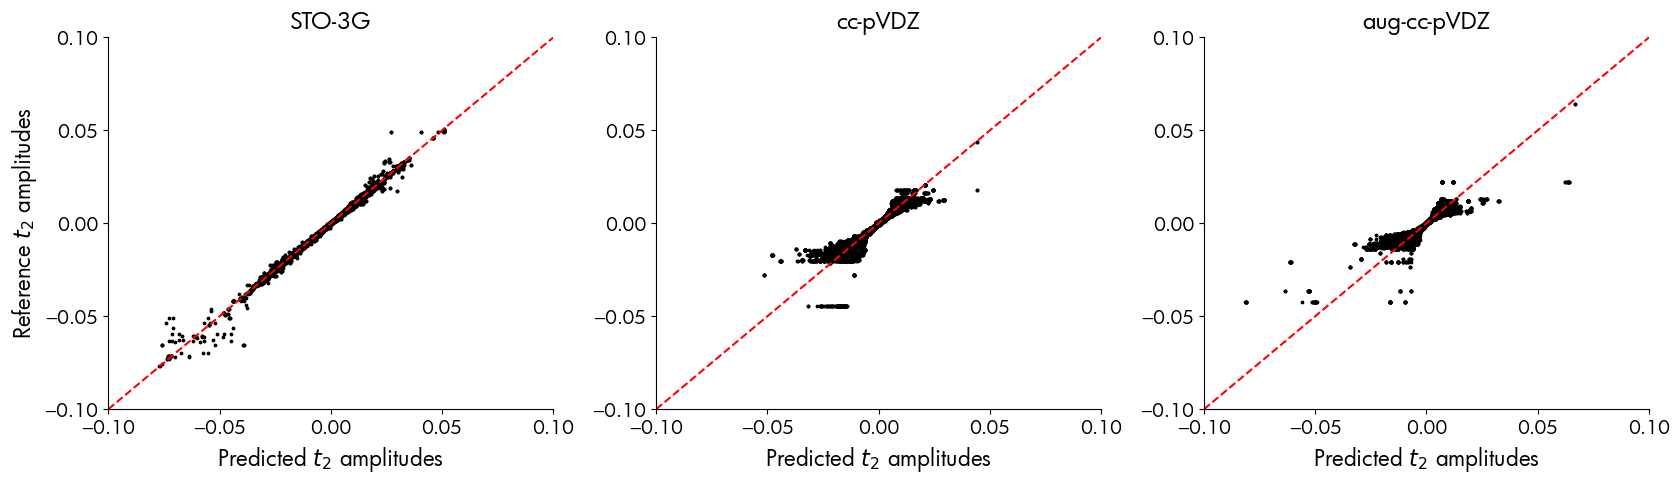

In [36]:
fig = plt.figure(figsize=(18, 5))
#gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05]) 

predictions = [y_pred, y_pred_2, y_pred_3]
tests_subsets = [y_test, y_test_2, y_test_3]
titles = ["STO-3G", "cc-pVDZ", "aug-cc-pVDZ"]

axs = [plt.subplot(gs[i]) for i in range(3)]

for i, (y_p, title) in enumerate(zip(predictions, titles)):
    axs[i].plot([-0.1, 0.1], [-0.1, 0.1], color='red', linestyle='--', label='Perfect Fit')
    axs[i].scatter(tests_subsets[i], y_p, color='black', label='Predicted vs Reference', s=3)
    
    axs[i].set_title(title, fontsize=17)
    axs[i].set_xlim(-0.1, 0.1)
    axs[i].set_ylim(-0.1, 0.1)

    xticks = [-0.1, -0.05, 0.00, 0.05, 0.1]
    axs[i].set_xticks(xticks)
    axs[i].set_yticks(xticks)
    axs[i].tick_params(axis='both', labelsize=14)


    axs[i].set_xlabel('Predicted $t_2$ amplitudes', fontsize=16)
    axs[i].spines['top'].set_color('none')
    axs[i].spines['right'].set_color('none')

axs[0].set_ylabel('Reference $t_2$ amplitudes', fontsize=16)

#cax = plt.subplot(gs[3])
#cbar = fig.colorbar(hb, cax=cax)
#cbar.set_label('Count', fontsize=16)

plt.tight_layout()
#plt.savefig("combined_pred.svg", format='svg', dpi=300)
plt.show()

/tmp/ipykernel_3418/1648499019.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


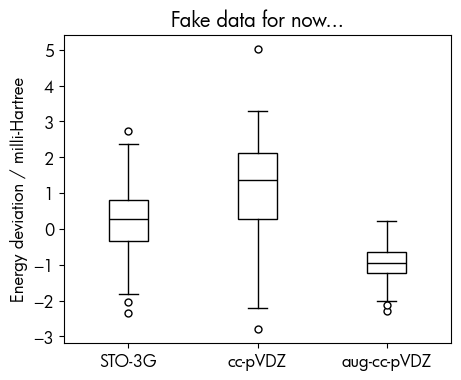

In [37]:

fake_data = [
    np.random.normal(loc=0, scale=1, size=100),   # STO-3g
    np.random.normal(loc=1, scale=1.5, size=100), # cc-pVDZ
    np.random.normal(loc=-1, scale=0.5, size=100) # aug-cc-pVDZ
]

fig, ax = plt.subplots(figsize=(5, 4))

ax.boxplot(
    fake_data,
    labels=["STO-3G", "cc-pVDZ", "aug-cc-pVDZ"],
    patch_artist=True,
    boxprops=dict(facecolor="white", color="black"),
    medianprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(markerfacecolor="white", marker="o", markersize=5, linestyle="none", markeredgecolor="black")
)

plt.ylabel("Energy deviation / milli-Hartree", labelpad=4)
plt.title("Fake data for now...")
#plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("figs/boxplot.png", dpi=300)
plt.show()

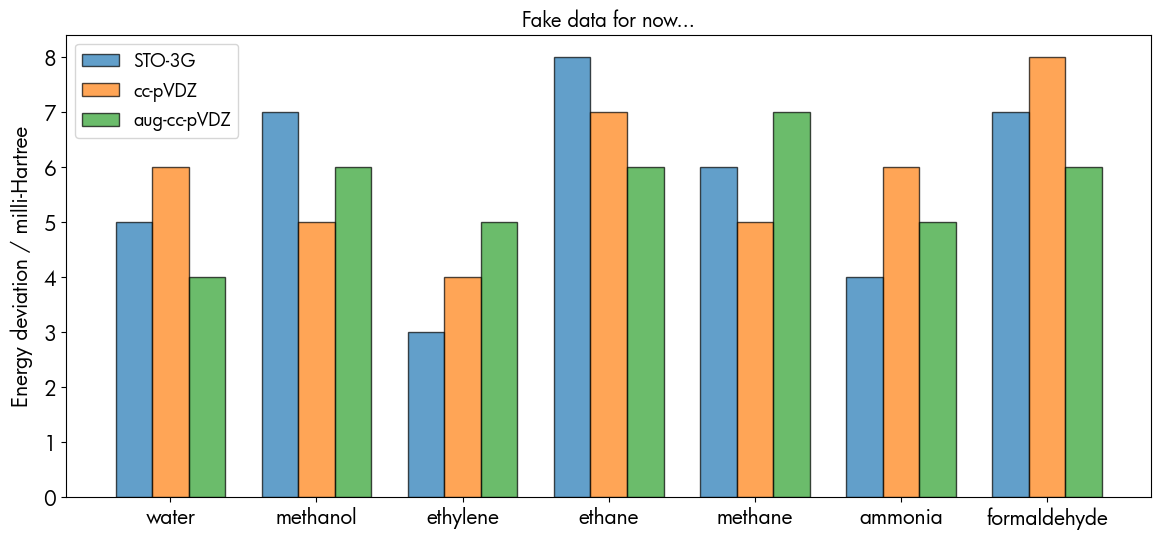

In [38]:
fig, ax = plt.subplots(figsize=(14, 6))

molecules = ['water', 'methanol', 'ethylene', 'ethane', 'methane', 'ammonia', 'formaldehyde']
# water, methanol, ethylene, ethane, methane, ammonia, and formaldehyde

values1 = [5, 7, 3, 8, 6, 4, 7]  # STO-3G
values2 = [6, 5, 4, 7, 5, 6, 8]  # cc-pVDZ
values3 = [4, 6, 5, 6, 7, 5, 6]  # aug-cc-pVDZ

x = np.arange(len(molecules))
width = 0.25  # width of each bar

plt.bar(x - width, values1, width, label='STO-3G', alpha=0.7, edgecolor='black')
plt.bar(x, values2, width, label='cc-pVDZ', alpha=0.7, edgecolor='black')
plt.bar(x + width, values3, width, label='aug-cc-pVDZ', alpha=0.7, edgecolor='black')

plt.xticks(x, molecules, fontsize=15)
plt.yticks(fontsize=15)

plt.ylabel('Energy deviation / milli-Hartree', labelpad=8, fontsize=15)

plt.legend(fontsize=13)
plt.title("Fake data for now...")
plt.savefig("figs/barchart.png", dpi=300)
plt.show()

## STO-3G performance
N: 10, MAE: 0.0003061269979620203, RMSE: 0.0037640880640455827, R2: 0.7676764878231661 <br>
N: 20, MAE: 0.0001429775419770101, RMSE: 0.0006323885667943092, R2: 0.9934424496700677 <br>
N: 40, MAE: 0.00011416410932380572, RMSE: 0.0005225211895203638, R2: 0.9955230584213859 <br>
N: 60, MAE: 0.00010775413538942215, RMSE: 0.0005084098074196536, R2: 0.9957616047642376 <br>
N: 80, MAE: 0.00010253405042620865, RMSE: 0.0005019661664701043, R2: 0.995868359698306 <br>
N: 100, MAE: 9.970629861774098e-05, RMSE: 0.0005165228029624035, R2: 0.9956252563277743 <br>

## cc-pVDZ performance
N: 10, MAE: 3.402683789446091e-05, RMSE: 0.0003901514662986885, R2: 0.9003862299546302 <br>
N: 20, MAE: 3.2123023381844337e-05, RMSE: 0.00038354509787292835, R2: 0.9037311546755417 <br>
N: 40, MAE: 3.12251442698022e-05, RMSE: 0.00038237019846431, R2: 0.9043200448636717 <br>
N: 60, MAE: 3.042337738702325e-05, RMSE: 0.0003758427821800151, R2: 0.9075588544494972 <br>
N: 80, MAE: 3.0591378528603053e-05, RMSE: 0.00037828073988276025, R2: 0.906355699550255 <br>
N: 100, MAE: 3.0265083450369752e-05, RMSE: 0.00037849364254374877, R2: 0.9062502607630246 <br>

## aug-cc-pVDZ performance
N: 10, MAE: 1.913434451136634e-05, RMSE: 0.00018596208617857802, R2: 0.9250580307897667 <br>
N: 20, MAE: 1.8468496450280462e-05, RMSE: 0.00018422700135631824, R2: 0.9264499710763333 <br>
N: 40, MAE: 1.80019375133377e-05, RMSE: 0.00018315347662328587, R2: 0.9273046527877226 <br>
N: 60, MAE: 1.7812372197703567e-05, RMSE: 0.00018064810472378655, R2: 0.9292798618341043 <br>
N: 80, MAE: 1.7949678302887403e-05, RMSE: 0.0001819042758903047, R2: 0.9282929102164369 <br>
N: 100, MAE: 1.7797565529948354e-05, RMSE: 0.00018030884122130993, R2: 0.9295452422230965 <br>

In [46]:
samples = [10, 20, 40, 60, 80, 100]

theory = ['STO-3G', 'cc-pVDZ', 'aug-cc-pVDZ']

mae_results = {
    'STO-3G': [
        0.0003061269979620203,
        0.0001429775419770101,
        0.00011416410932380572,
        0.00010775413538942215,
        0.00010253405042620865,
        9.970629861774098e-05
    ],
    'cc-pVDZ': [
        3.402683789446091e-05,
        3.2123023381844337e-05,
        3.12251442698022e-05,
        3.042337738702325e-05,
        3.0591378528603053e-05,
        3.0265083450369752e-05
    ],
    'aug-cc-pVDZ': [
        1.913434451136634e-05,
        1.8468496450280462e-05,
        1.80019375133377e-05,
        1.7812372197703567e-05,
        1.7949678302887403e-05,
        1.7797565529948354e-05
    ]
}

rmse_results = {
    'STO-3G': [
        0.0037640880640455827,
        0.0006323885667943092,
        0.0005225211895203638,
        0.0005084098074196536,
        0.0005019661664701043,
        0.0005165228029624035
    ],
    'cc-pVDZ': [
        0.0003901514662986885,
        0.00038354509787292835,
        0.00038237019846431,
        0.0003758427821800151,
        0.00037828073988276025,
        0.00037849364254374877
    ],
    'aug-cc-pVDZ': [
        0.00018596208617857802,
        0.00018422700135631824,
        0.00018315347662328587,
        0.00018064810472378655,
        0.0001819042758903047,
        0.00018030884122130993
    ]
}

r2_results = {
    'STO-3G': [
        0.7676764878231661,
        0.9934424496700677,
        0.9955230584213859,
        0.9957616047642376,
        0.995868359698306,
        0.9956252563277743
    ],
    'cc-pVDZ': [
        0.9003862299546302,
        0.9037311546755417,
        0.9043200448636717,
        0.9075588544494972,
        0.906355699550255,
        0.9062502607630246
    ],
    'aug-cc-pVDZ': [
        0.9250580307897667,
        0.9264499710763333,
        0.9273046527877226,
        0.9292798618341043,
        0.9282929102164369,
        0.9295452422230965
    ]
}

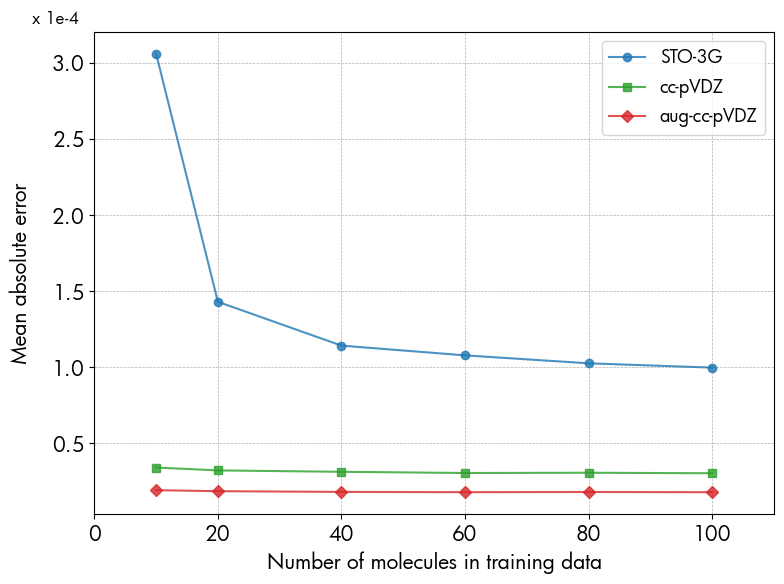

In [40]:
styles = {
    "STO-3G": {"color": "tab:blue", "marker": "o"},
    "cc-pVDZ": {"color": "tab:green", "marker": "s"},
    "aug-cc-pVDZ": {"color": "tab:red", "marker": "D"}
}

fig, ax = plt.subplots(figsize=(8, 6))

for model, mae in mae_results.items():
    scaled_mae = [m * 1e4 for m in mae]
    ax.plot(
        samples,
        scaled_mae,
        marker=styles[model]["marker"],
        color=styles[model]["color"],
        linestyle="-",
        label=model,
        markersize=6,
        linewidth=1.5,
        alpha=0.8
    )

ax.set_xlabel("Number of molecules in training data", fontsize=15)
ax.set_ylabel("Mean absolute error", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-4, -4))
ax.yaxis.set_major_formatter(formatter)

ax.ticklabel_format(style='plain', axis='y')
ax.tick_params(axis='both', which='major', labelsize=15)

ax.annotate("x 1e-4", xy=(0, 1), xycoords=('axes fraction', 'axes fraction'),
            xytext=(-45, 3), textcoords='offset points',
            ha='left', va='bottom', fontsize=12)

ax.legend(fontsize=13)
plt.tight_layout()
plt.xlim(0, 110)

plt.savefig("figs/mae_across_basis_sets.svg", format='svg', dpi=300)
plt.show()

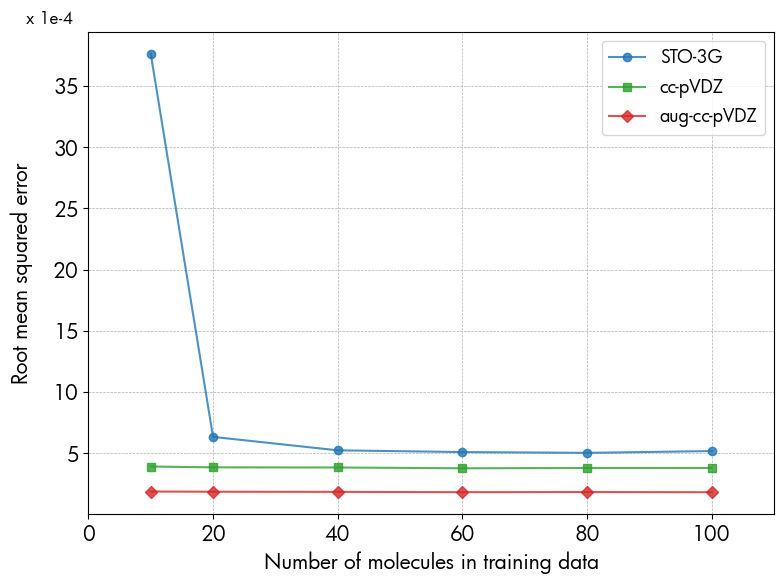

In [53]:
styles = {
    "STO-3G": {"color": "tab:blue", "marker": "o"},
    "cc-pVDZ": {"color": "tab:green", "marker": "s"},
    "aug-cc-pVDZ": {"color": "tab:red", "marker": "D"}
}

fig, ax = plt.subplots(figsize=(8, 6))

for model, rmse in rmse_results.items():
    scaled_rmse = [m * 1e4 for m in rmse]
    
    ax.plot(
        samples,
        scaled_rmse,
        marker=styles[model]["marker"],
        color=styles[model]["color"],
        linestyle="-",
        label=model,
        markersize=6,
        linewidth=1.5,
        alpha=0.8
    )

ax.set_xlabel("Number of molecules in training data", fontsize=15)
ax.set_ylabel("Root mean squared error", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-4, -4))
ax.yaxis.set_major_formatter(formatter)

ax.ticklabel_format(style='plain', axis='y')
ax.tick_params(axis='both', which='major', labelsize=15)

ax.annotate("x 1e-4", xy=(0, 1), xycoords=('axes fraction', 'axes fraction'),
            xytext=(-45, 3), textcoords='offset points',
            ha='left', va='bottom', fontsize=12)

ax.legend(fontsize=13)
plt.tight_layout()
plt.xlim(0, 110)

#plt.savefig("figs/mae_across_basis_sets.svg", format='svg', dpi=300)
plt.show()

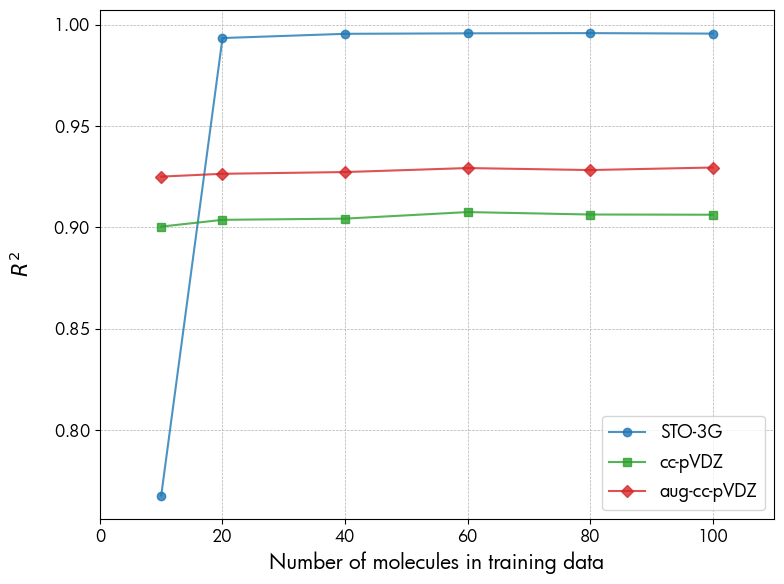

In [54]:
styles = {
    "STO-3G": {"color": "tab:blue", "marker": "o"},
    "cc-pVDZ": {"color": "tab:green", "marker": "s"},
    "aug-cc-pVDZ": {"color": "tab:red", "marker": "D"}
}

fig, ax = plt.subplots(figsize=(8, 6))

for model, r2 in r2_results.items():
    
    ax.plot(
        samples,
        r2,
        marker=styles[model]["marker"],
        color=styles[model]["color"],
        linestyle="-",
        label=model,
        markersize=6,
        linewidth=1.5,
        alpha=0.8
    )

ax.set_xlabel("Number of molecules in training data", fontsize=15)
ax.set_ylabel("$R^2$", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)

#formatter = ScalarFormatter(useMathText=True)
#formatter.set_powerlimits((-4, -4))
ax.yaxis.set_major_formatter(formatter)

#ax.ticklabel_format(style='plain', axis='y')
#ax.tick_params(axis='both', which='major', labelsize=15)

#ax.annotate("x 1e-4", xy=(0, 1), xycoords=('axes fraction', 'axes fraction'),
#            xytext=(-45, 3), textcoords='offset points',
#            ha='left', va='bottom', fontsize=12)

ax.legend(fontsize=13)
plt.tight_layout()
plt.xlim(0, 110)

#plt.savefig("figs/mae_across_basis_sets.svg", format='svg', dpi=300)
plt.show()

In [41]:
n_list = [10, 20, 40, 60, 80, 100]
basis_sets = ["STO-3G", "aug-cc-pVDZ"]

for basis in basis_sets:
    print(f"Basis: {basis}")

    data = joblib.load(f"water_out/{basis}_test_data_splits.pkl")
    X_test = data["X_test"]
    y_test = data["y_test"]

    for n in n_list:
        print(f"Train size: {n}")
        data = joblib.load(f"water_out/{basis}_train_data_splits_{n}.pkl")
        
        X_train = data["X_train"]
        y_train = data["y_train"]
        
             
        model = RandomForestRegressor()
            
        model_pipeline = Pipeline([
            ('scaler', MinMaxScaler(feature_range=(-1,1))),
            ('regressor', model)
        ])
            
        # fit model
        t1 = time.time()
        model_pipeline.fit(X_train, y_train)
        t2 = time.time()
        y_pred = model_pipeline.predict(X_test)
        
        # compute performance metrics
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = root_mean_squared_error(y_test, y_pred)
    
        with open("water_out/deletemodel.pkl", "wb") as f:
            joblib.dump(model, f)
    
        file_size = os.path.getsize("water_out/deletemodel.pkl")
        print(f"Model size: {file_size / 1e6:.2f} MB")
        
        print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}, Training time {t2-t1}\n")

Basis: STO-3G
Train size: 10
Model size: 3.97 MB
N: 10, MAE: 1.4386572993726832e-05, RMSE: 8.329493600165953e-05, R2: 0.9999724420062144, Training time 0.6027512550354004

Train size: 20
Model size: 7.47 MB
N: 20, MAE: 8.465199506899687e-06, RMSE: 7.703760186698305e-05, R2: 0.9999764269427904, Training time 1.0470716953277588

Train size: 40
Model size: 14.32 MB
N: 40, MAE: 6.060983388005975e-06, RMSE: 5.800965376137235e-05, R2: 0.9999866337079278, Training time 2.130986452102661

Train size: 60
Model size: 20.94 MB
N: 60, MAE: 5.422009094746536e-06, RMSE: 5.831575816843171e-05, R2: 0.9999864922736811, Training time 3.2356808185577393

Train size: 80
Model size: 26.22 MB
N: 80, MAE: 4.43886459047999e-06, RMSE: 4.1473484519884034e-05, R2: 0.9999931679434709, Training time 4.508204460144043

Train size: 100
Model size: 31.29 MB
N: 100, MAE: 3.67981114074179e-06, RMSE: 3.820313754180905e-05, R2: 0.9999942029310713, Training time 5.727548599243164

Basis: aug-cc-pVDZ


FileNotFoundError: [Errno 2] No such file or directory: 'water_out/aug-cc-pVDZ_test_data_splits.pkl'

In [ ]:
n_list = [10, 20, 40, 60, 80, 100]
basis_sets = ["STO-3G", "aug-cc-pVDZ"]

for basis in basis_sets:
    print(f"Basis: {basis}")

    data = joblib.load(f"water_out/{basis}_test_data_splits.pkl")
    X_test = data["X_test"]
    y_test = data["y_test"]

    for n in n_list:
        print(f"Train size: {n}")
        data = joblib.load(f"water_out/{basis}_train_data_splits_{n}.pkl")
        
        X_train = data["X_train"]
        y_train = data["y_train"]
        
             
        model = xgb.XGBRegressor()
            
        model_pipeline = Pipeline([
            ('scaler', MinMaxScaler(feature_range=(-1,1))),
            ('regressor', model)
        ])
            
        # fit model
        t1 = time.time()
        model_pipeline.fit(X_train, y_train)
        t2 = time.time()
        y_pred = model_pipeline.predict(X_test)
        
        # compute performance metrics
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = root_mean_squared_error(y_test, y_pred)
    
        with open("water_out/deletemodel.pkl", "wb") as f:
            joblib.dump(model, f)
    
        file_size = os.path.getsize("water_out/deletemodel.pkl")
        print(f"Model size: {file_size / 1e6:.2f} MB")
        
        print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}, Training time {t2-t1}\n")

In [ ]:
samples = [10, 20, 40, 60, 80, 100]

theory = ['RandomForestRegressor', 'XGBoost']

size_results = {
    'RandomForestRegressor': [
        3.95, 7.49, 14.36, 20.96, 26.20, 31.26
    ],
    'XGBoost': [
        0.08, 0.09, 0.09, 0.09, 0.09, 0.09  
    ]
}

In [ ]:
from matplotlib.ticker import ScalarFormatter

styles = {
    "RandomForestRegressor": {"color": "tab:blue", "marker": "o"},
    "XGBoost": {"color": "tab:red", "marker": "D"}
}

fig, ax = plt.subplots(figsize=(8, 6))

for model, size in size_results.items():
    ax.plot(
        samples,
        size,
        marker=styles[model]["marker"],
        color=styles[model]["color"],
        linestyle="-",
        label=model,
        markersize=6,
        linewidth=1.5,
        alpha=0.8
    )

# set log scale on y-axis
ax.set_yscale("log")

# axis labels
ax.set_xlabel("Number of molecules in training data", fontsize=15)
ax.set_ylabel("Model size", fontsize=15, labelpad=14)

# grid lines
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

# use plain numbers (not scientific notation) for log axis ticks
#ax.yaxis.set_major_formatter(ScalarFormatter())
#ax.tick_params(axis='both', which='major', labelsize=15)

# legend
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("figs/random_forest_scaling.png", dpi=300)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(samples, mae_results['STO-3G'], 's-', label='MAE', color='black', markersize=5)

ax.set_xlabel("Number of training data", fontsize=15)
ax.set_ylabel("Mean absolute error", fontsize=15)

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

#ax.set_yscale("log")

# Use scalar formatter with scientific notation
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-4, -4))  # Force 10^-4 scaling
ax.yaxis.set_major_formatter(formatter)

plt.xlim(0, 110)
plt.title("STO-3G")
plt.tight_layout()
plt.show()


# Average over molecules

In [ ]:
import psutil
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd
#import tensorflow as tf
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from sklearn.metrics import mean_absolute_error, r2_score

from glob import glob
import psi4
from helper_CC_ML_spacial import HelperCCEnergy
# from helper_CC_ML import *

from glob import glob
import random

In [ ]:
properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag']

In [ ]:
with open('out_of_data.txt','r') as f:
    lines = f.readlines()
    
filenames = [element[:-1] for element in lines]
filenames[:4]

In [ ]:
basis_sets = ['STO-3G','cc-pVDZ','aug-cc-pVDZ']
best5=["doublecheck","t2start","t2mag","orbdiff","diag"]

n_list = [20, 40, 60, 80, 100] # iterating over N=20,40,60,80,100 training molecules
n_list = [20]
mean_deviations = []
mean_iter_to_converge = []

for basis in basis_sets:
    for n in n_list:
        print(f"Processing N={n} molecules with {basis} basis set")

        data_path = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/out/faster_{basis}_data_splits_{n}.pkl"
        print(data_path)
        print("Training model..")

        with open(data_path,'rb') as f:
            data = joblib.load(f)            # import model

        X_train = data["X_train"]
        y_train = data["y_train"]
        X_test = data["X_test"]
        y_test = data["y_test"]
        
         
        model = xgb.XGBRegressor(
            n_estimators=400,
            max_depth=12,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            reg_alpha=0.0,
            tree_method="hist",
            n_jobs=-1,
            random_state=42
        )
        
        model_pipeline = Pipeline([
            ('scaler', MinMaxScaler(feature_range=(-1,1))),
            ('regressor', model)
        ])

        t1 = time.time()
        model_pipeline.fit(X_train, y_train)
        t2 = time.time()
        
        y_pred = model_pipeline.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        
        print(f"N: {n}, MAE: {mae}, MSE: {mse}, R2: {r2}")
        print(f"Finished training in {t2-t1} seconds \n")
        
        ml_iter_list = []
        ml_dev = []
        ml_time_to_converge_list = []
        for fn in filenames[:50]:
            print(f"Processing {fn}")       # import xyz file
            with open(fn,'r') as f:
                text=f.read()
            mol = psi4.geometry(text)                
            
            psi4.core.clean()
            psi4.core.be_quiet()
            
            psi4.set_options({'basis': basis,
                              'scf_type':     'pk',
                              'reference':    'rohf',
                              'mp2_type':     'conv',
                              'e_convergence': 1e-8,
                              'd_convergence': 1e-8})

            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            
            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)
            # Here is the "normal" way to initialize i.e. NOT Machine Learning predicted, NOT random, NOT all zeros
            MP2T2=A.t2start
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = MP2T2

            # GMJ go back and fix these lists to save this data
            MP2E = A.compute_energy(iterate=False)# MP2 (initial) energy
            CCSDE = A.compute_energy()# exact CCSD energy
        
            normal_dev.append(abs(MP2E-CCSDE))  # energy deviation from CCSD
            
            # Here we are initializing with the ML predicted t2-amplitudes, first we predict using the top 5 features
            y_pred = model.predict(np.vstack([getattr(A,i).flatten() for i in best5]).T)
            
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = y_pred.reshape(*A.t2.shape)
            A.t2start = y_pred.reshape(*A.t2.shape)

            # mlE_0 = A.compute_energy(iterate=False)   # GMJ this is MP2 energy
            mlE = A.compute_energy()                # GMJ exact CCSD energy calculated using injected DDCC parameters 
                    
            ml_dev.append(abs(MP2E-mlE))  # energy deviation from MP2
            ml_dev.append(abs(CCSDE-mlE))  # energy deviation from CCSD
            
            mlHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
            mlHistory.insert(0, (0,mlE_0))     # inserting the INITIAL t2 amplitude from ML method
            
            #for i in mlHistory:
            #    print(i)
            #print("\n")
            
            iterations = len(mlHistory)     # number of iterations to converge
            #print(f"No. of iterations to converge: {iterations}")
            ml_iter_list.append(iterations)
            
            ml_time_to_converge = A.time_to_converge 
            ml_time_to_converge_list.append(ml_time_to_converge)
            #print(f"Time to converge: {ml_time_to_converge}")
            
            features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
            #print(f"Features: \n{features}")

        print("\n")
        print("Iterations for each molecule list: ", ml_iter_list)
        print("Mean iterations to converge: ", np.mean(ml_iter_list))
        print("Deviations from CCSD for each molecule: ", ml_dev)
        print(f"Mean deviation from CCSD: {np.mean(ml_dev)} (Eₕ)")
        print("Times to converge for each molecule: ", ml_time_to_converge_list)
        print("Mean time to converge", np.mean(ml_time_to_converge_list), " seconds")

        mean_deviations.append((basis, n, np.mean(ml_dev)))
        mean_iter_to_converge.append((basis, n, np.mean(ml_iter_list)))
        print("aa: here: ", mean_deviations)
        print("Next model...\n")


In [ ]:
mean_deviations

In [ ]:
mean_iter_to_converge

In [ ]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, dev in mean_deviations:
    grouped[basis][0].append(n)
    grouped[basis][1].append(dev * 1000)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Deviation from CCSD (m$E_h$)", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()

In [ ]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, it in mean_iter_to_converge:
    grouped[basis][0].append(n)
    grouped[basis][1].append(it)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Iterations to Convergence", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()

In [ ]:
################

In [ ]:
fn = "out/test_names.txt"
with open(fn, 'r') as f:
    filenames = [line.strip() for line in f]

print(filenames)

In [ ]:
basis_sets = ['aug-cc-pVDZ']
best5=["doublecheck","t2start","t2mag","orbdiff","diag"]

n_list = [10, 20, 40, 60, 80, 100] # iterating over N=10, 20, 40, 60, 80, 100 training molecules
n_list = [100]

mean_deviations = []
mean_iter_to_converge = []

for basis in basis_sets:
    for n in n_list:
        print(f"Processing N={n} molecules with {basis} basis set")
        
        fn = f"out/optimised_{basis}_best_model_{n}.pkl"
        model = joblib.load(fn)
        
        ml_iter_list = []
        ml_dev = []
        ml_time_to_converge_list = []
        for fn in filenames:
            print(f"Processing {fn}")       # import xyz file
            with open(fn,'r') as f:
                text=f.read()
            mol = psi4.geometry(text)                
            
            psi4.core.clean()
            psi4.core.be_quiet()
            
            psi4.set_options({'basis': basis,
                              'scf_type':     'pk',
                              'reference':    'rohf',
                              'mp2_type':     'conv',
                              'e_convergence': 1e-8,
                              'd_convergence': 1e-8})

            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            
            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)

            MP2T2=A.t2start
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = MP2T2
            
            MP2E = A.compute_energy(iterate=False)                    # MP2 (initial) energy
            CCSDE = A.compute_energy() 
            

            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)
            
            # Here we are initializing with the ML predicted t2-amplitudes, first we predict using the top 5 features
            y_pred = model.predict(np.vstack([getattr(A,i).flatten() for i in top5]).T)
            
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = y_pred.reshape(*A.t2.shape)
            A.t2start = y_pred.reshape(*A.t2.shape)

            mlE_0 = A.compute_energy(iterate=False)   # ML-predicted energy
            #mlE = A.compute_energy()                # exact CCSD energy

            
            ml_dev.append(abs(mlE_0-CCSDE))  # energy deviation from CCSD


            print("Deviation here: ", abs(mlE_0-CCSDE), "\n")
            
            mlHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
            mlHistory.insert(0, (0,mlE_0))     # inserting the INITIAL t2 amplitude from ML method
            
            #for i in mlHistory:
            #    print(i)
            #print("\n")
            
            iterations = len(mlHistory)     # number of iterations to converge
            #print(f"No. of iterations to converge: {iterations}")
            ml_iter_list.append(iterations)
            
            ml_time_to_converge = A.time_to_converge 
            ml_time_to_converge_list.append(ml_time_to_converge)
            #print(f"Time to converge: {ml_time_to_converge}")
            
            features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in top5]).T,columns=top5)
            #print(f"Features: \n{features}")

        print("\n")
        print("Iterations for each molecule list: ", ml_iter_list)
        print("Mean iterations to converge: ", np.mean(ml_iter_list))
        print("Deviations from CCSD for each molecule: ", ml_dev)
        print(f"Mean deviation from CCSD: {np.mean(ml_dev)} (Eₕ)")
        print("Times to converge for each molecule: ", ml_time_to_converge_list)
        print("Mean time to converge", np.mean(ml_time_to_converge_list), " seconds")

        mean_deviations.append((basis, n, np.mean(ml_dev)))
        mean_iter_to_converge.append((basis, n, np.mean(ml_iter_list)))
        print("aa: here: ", mean_deviations)
        print("Next model...\n")


In [ ]:
mean_deviations

In [ ]:
mean_iter_to_converge

In [ ]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, dev in mean_deviations:
    grouped[basis][0].append(n)
    grouped[basis][1].append(dev * 1000)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Deviation from CCSD (m$E_h$)", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()

In [ ]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, it in mean_iter_to_converge:
    grouped[basis][0].append(n)
    grouped[basis][1].append(it)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Iterations to Convergence", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()